# Eval-suite latency and token usage

Compare wall-clock time and tokens generated across the 5 OOD test sets (wildguardmix, aegis, toxic-chat, openai-moderation, xstest) for our headline safety classifiers.

**Models compared**
- *WildGuard 7B* — prior-work, 3-line structured classification
- *NVIDIA Nemotron Content-Safety 4B* — prior-work, reasoning
- *GuardReasoner 8B* — prior-work, long CoT reasoning
- *OpenAI gpt-oss-safeguard 120B* — prior-work, reasoning
- *Llama-3.1-8B SFT generation* — our own fine-tune (intent + harm)
- *Gemma-3-12B SFT generation* — released Jazhyc/gemma-3-12b-intent-jailbreak-classifier
- *Llama-3.1-8B LE-DPO* — LE-DPO on top of Llama SFT (k10-e-hard, β=0.3, 3ep, seed 22)
- *Llama-3.1-8B GRPO* — iustinsirbu/llama-3.1-8b-grpo-intent-safety (reasoning + intent)
- *Llama-3.1-8B Distill* — gpt-oss-120b → llama-3.1-8b, synthetic_intent, lr=1e-4, v7 (competitive at F1 ~0.82)
- *Gemma-3-12B Distill* — gpt-oss-120b → gemma-3-12b, human_intent, lr=2e-5, v7 (best distill)

LlamaGuard 4 (12B) and ShieldGemma 27B suite summaries are also on disk (and read by `scripts/backfill_eval_timing.py`), but excluded from the scatter because their low F1 (<0.71) and, for ShieldGemma, large 53 ms/example stretch the axes and obscure the interesting cluster.

**Data source.** Per-(dataset, condition) timing was backfilled from W&B via `scripts/backfill_eval_timing.py` into local `*_suite_summary.json` files under `data/safety_experiment/`. Future eval runs save the same JSON directly (see `scripts/eval_safety_classifier.py`), so this notebook never needs to talk to W&B.

**Caveat.** Eval used vLLM continuous batching: the full test set is submitted in one `llm.generate()` call. The numbers here are *wall-clock time to finish the entire OOD suite* on the SLURM-allocated GPU. They do not reflect single-request latency. The data here pins to the `rtx_pro_6000` partition for hardware fairness; if a model is missing from the chart, its job hasn't finished yet.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Resolve repo root relative to this notebook (notebooks/baselines/).
REPO = Path('.').resolve().parents[1]
DATA = REPO / 'data' / 'safety_experiment'

# OOD test sets in scope. annotated-intents is in-domain and excluded from the suite total.
OOD_DATASETS = ['wildguardmix', 'aegis', 'toxic-chat', 'openai-moderation', 'xstest']

# A few models have a `paper_mean_ood_f1` override — the F1 reported in the paper
# (averaged over multiple seeds / runs). Local eval F1 can drift by ~±0.005 from
# hardware noise and single-seed runs; the override keeps this notebook aligned
# with the paper's headline numbers.
#
# `group` separates prior-work classifiers from our own fine-tunes for the scatter
# coloring. LlamaGuard 4 (12B) and ShieldGemma (27B) suite summaries exist on disk
# but are excluded here because their F1 (<0.71) and ShieldGemma's 53 ms/ex stretch
# the scatter axes too far and squash the interesting cluster around F1 0.79–0.84.
MODELS = [
    {
        'label': 'WildGuard 7B',
        'kind': 'classification (3-line)',
        'group': 'prior',
        'path': DATA / 'allenai_wildguard_wildguard_classification_suite_summary.json',
    },
    {
        'label': 'Nemotron Safety 4B',
        'kind': 'classification (reasoning)',
        'group': 'prior',
        'path': DATA / 'nvidia_Nemotron-Content-Safety-Reasoning-4B_nemotron_classification_suite_summary.json',
    },
    {
        'label': 'GuardReasoner 8B',
        'kind': 'classification (reasoning)',
        'group': 'prior',
        'path': DATA / 'yueliu1999_GuardReasoner-8B_guardreasoner_classification_suite_summary.json',
    },
    {
        'label': 'GPT OSS Safeguard 120B',
        'kind': 'classification (reasoning)',
        'group': 'prior',
        'path': DATA / 'openai_gpt-oss-safeguard-120b_safeguard_classification_suite_summary.json',
    },
    {
        'label': 'Llama-3.1-8B SFT',
        'kind': 'generation',
        'group': 'ours',
        'path': DATA / 'sft' / 'meta-llama_Llama-3.1-8B-Instruct_finetuned_generation_suite_summary.json',
    },
    {
        'label': 'Gemma-3-12B SFT',
        'kind': 'generation',
        'group': 'ours',
        'path': DATA / 'sft' / 'google_gemma-3-12b-it_finetuned_generation_suite_summary.json',
    },
    {
        'label': 'Llama-3.1-8B LE-DPO',
        'kind': 'generation (LE-DPO)',
        'group': 'ours',
        'path': DATA / 'dpo' / 'llama31-8b-k10-e-hard-b03-e3-s22'
                / 'meta-llama_Llama-3.1-8B-Instruct_finetuned_generation_suite_summary.json',
        'paper_mean_ood_f1': 0.812,
    },
    {
        'label': 'Llama-3.1-8B GRPO',
        'kind': 'reasoning + intent (GRPO)',
        'group': 'ours',
        'path': DATA / 'iustinsirbu_llama-3.1-8b-grpo-intent-safety_grpo_classification_suite_summary.json',
        'paper_mean_ood_f1': 0.836,
    },
    {
        'label': 'Llama-3.1-8B Distill',
        'kind': 'reasoning + synthetic_intent',
        'group': 'ours',
        'path': DATA / 'distillation' / 'openai-gpt-oss-120b' / 'llama-3.1-8b' / 'synthetic_intent'
                / 'meta-llama_Llama-3.1-8B-Instruct_finetuned_reasoning_synthetic_intent_suite_summary.json',
    },
    {
        'label': 'Gemma-3-12B Distill',
        'kind': 'reasoning + human_intent',
        'group': 'ours',
        'path': DATA / 'distillation' / 'openai-gpt-oss-120b' / 'gemma-3-12b' / 'human_intent'
                / 'google_gemma-3-12b-it_finetuned_reasoning_human_intent_suite_summary.json',
    },
]

# Drop any models whose suite summary hasn't landed yet so the notebook stays runnable
# while eval jobs are in flight.
missing_models = [m['label'] for m in MODELS if not m['path'].exists()]
MODELS = [m for m in MODELS if m['path'].exists()]
if missing_models:
    print(f'⚠️  Skipping (no suite summary yet): {missing_models}')

print(f'Repo root: {REPO}')
print(f'Loaded {len(MODELS)} suite-summary files.')


def _count_jsonl_records(suite_path: Path, model_slug: str, condition: str, dataset_name: str) -> int:
    """Source-of-truth example count: lines in the local prediction .jsonl.

    Some W&B runs logged ``total = 0`` because a downstream parser failed at log
    time; the .jsonl always has the true record count for examples the model
    processed (and is what wall-clock time was paid for).
    """
    jsonl = suite_path.parent / dataset_name / f"{model_slug}_{condition}.jsonl"
    if not jsonl.exists():
        return 0
    with open(jsonl, 'rb') as f:
        return sum(1 for _ in f)


def _recompute_f1_from_jsonl(
    suite_path: Path, model_slug: str, condition: str, dataset_name: str
) -> float:
    """Compute binary harm F1 from the local prediction .jsonl.

    Used as a fallback when the suite summary's F1 is missing/0 (some W&B runs
    logged metrics=0 due to a logging-time parser bug; the .jsonl predictions
    are still correct). Returns 0.0 if no records have both labels populated.
    """
    jsonl = suite_path.parent / dataset_name / f"{model_slug}_{condition}.jsonl"
    if not jsonl.exists():
        return 0.0
    tp = fp = fn = 0
    with open(jsonl) as f:
        for line in f:
            r = json.loads(line)
            t = r.get('true_harm_binary')
            p = r.get('predicted_harm')
            if t is None or p is None:
                continue
            if p == 'harmful' and t == 'harmful':
                tp += 1
            elif p == 'harmful' and t == 'safe':
                fp += 1
            elif p == 'safe' and t == 'harmful':
                fn += 1
    if tp == 0 and (fp == 0 or fn == 0):
        return 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

Repo root: /scratch/s4626451/intention-jailbreak
Loaded 10 suite-summary files.


## Aggregate across the OOD suite

In [2]:
rows = []
per_dataset_rows = []
for m in MODELS:
    summary = json.loads(m['path'].read_text())
    model_slug = summary['model_slug']
    # Accept both shapes: live-eval writes only `conditions` (plural list);
    # the W&B backfill writes both singular `condition` and plural `conditions`.
    condition = summary.get('condition') or (summary.get('conditions') or [None])[0]
    elapsed = 0.0
    tokens = 0
    n = 0
    f1_sum = 0.0
    f1_count = 0
    covered = []
    missing = []
    for ds in OOD_DATASETS:
        # Find the (dataset, condition) entry matching this dataset.
        match = next((v for v in summary['runs'].values() if v['dataset_name'] == ds), None)
        if match is None:
            missing.append(ds)
            continue
        covered.append(ds)
        # n from W&B `total` is unreliable for runs where the parser failed
        # (e.g. Gemma SFT generation logged total=0 across all datasets). Read
        # the row count straight from the .jsonl instead.
        n_ds = _count_jsonl_records(m['path'], model_slug, condition, ds)
        elapsed += float(match.get('elapsed_s') or 0.0)
        tokens += int(match.get('total_tokens') or 0)
        n += n_ds
        # F1 from the summary, with a .jsonl-recompute fallback when the
        # summary's F1 is 0 (parser-failure bug at log time).
        f1 = float(match.get('f1') or 0.0)
        if f1 == 0.0:
            f1 = _recompute_f1_from_jsonl(m['path'], model_slug, condition, ds)
        if f1 > 0:
            f1_sum += f1
            f1_count += 1
        per_dataset_rows.append({
            'model': m['label'],
            'dataset': ds,
            'elapsed_s': float(match.get('elapsed_s') or 0.0),
            'total_tokens': int(match.get('total_tokens') or 0),
            'total_examples': n_ds,
            'f1': f1,
            'tokens_per_second': float(match.get('tokens_per_second') or 0.0),
        })
    computed_mean_f1 = f1_sum / f1_count if f1_count else float('nan')
    # Per-paper override (for models with multi-seed reported numbers); fall back
    # to the locally computed mean F1 otherwise.
    paper_f1 = m.get('paper_mean_ood_f1')
    mean_ood_f1 = paper_f1 if paper_f1 is not None else computed_mean_f1
    rows.append({
        'model': m['label'],
        'kind': m['kind'],
        'group': m.get('group', 'ours'),
        'datasets_covered': len(covered),
        'missing': ', '.join(missing) if missing else '—',
        'elapsed_s': elapsed,
        'total_tokens': tokens,
        'total_examples': n,
        'tokens_per_example': tokens / n if n else 0.0,
        # ms/example is the honest latency metric — tokens/s is misleading for models with
        # short outputs (prefill dominates, so short-output models look slow on tok/s).
        'ms_per_example': 1000 * elapsed / n if n else 0.0,
        'examples_per_second': n / elapsed if elapsed else 0.0,
        'tokens_per_second': tokens / elapsed if elapsed else 0.0,
        # Mean F1 actually used in the scatter / table. Either the paper override
        # or the locally-computed mean (with .jsonl fallback for parser-bug runs).
        'mean_ood_f1': mean_ood_f1,
        'mean_ood_f1_local': computed_mean_f1,
        'ood_f1_n_datasets': f1_count,
        'f1_source': 'paper' if paper_f1 is not None else 'local',
    })

suite = pd.DataFrame(rows)
per_ds = pd.DataFrame(per_dataset_rows)
suite

,model,kind,group,datasets_covered,missing,elapsed_s,total_tokens,total_examples,tokens_per_example,ms_per_example,examples_per_second,tokens_per_second,mean_ood_f1,mean_ood_f1_local,ood_f1_n_datasets,f1_source
0,WildGuard 7B,classification (3-line),prior,5,—,70.281417,250563,10876,23.038157,6.462065,154.749300,3565.138725,0.803775,0.803775,5,local
1,Nemotron Safety 4B,classification (reasoning),prior,5,—,89.162962,761921,10876,70.055259,8.198139,121.978900,8545.263451,0.808539,0.808539,5,local
2,GuardReasoner 8B,classification (reasoning),prior,5,—,344.060742,3109193,10876,285.876517,31.634860,31.610697,9036.756061,0.804356,0.804356,5,local
3,GPT OSS Safeguard 120B,classification (reasoning),prior,5,—,268.169186,1489128,10876,136.918720,24.656968,40.556487,5552.942245,0.807486,0.807486,5,local
4,Llama-3.1-8B SFT,generation,ours,5,—,50.723130,195019,10876,17.931133,4.663767,214.418944,3844.774559,0.791177,0.791177,5,local
5,Gemma-3-12B SFT,generation,ours,5,—,138.181183,679152,10876,62.445017,12.705147,78.708257,4914.938399,0.807798,0.807798,5,local
6,Llama-3.1-8B LE-DPO,generation (LE-DPO),ours,5,—,59.983311,280255,10876,25.768205,5.515200,181.317100,4672.216238,0.812000,0.814957,5,paper
7,Llama-3.1-8B GRPO,reasoning + intent (GRPO),ours,5,—,274.908311,2104584,10876,193.507172,25.276601,39.562282,7655.585207,0.836000,0.831939,5,paper
8,Llama-3.1-8B Distill,reasoning + synthetic_intent,ours,5,—,219.568341,1569131,10876,144.274641,20.188336,49.533553,7146.435550,0.820159,0.820159,5,local
9,Gemma-3-12B Distill,reasoning + human_intent,ours,5,—,358.997088,1578957,10876,145.178099,33.008191,30.295510,4398.244589,0.822399,0.822399,5,local


## Suite wall-clock time

`elapsed_s` is total wall-clock for the 5 OOD sets. `ms/example` is the honest per-prompt latency metric: it answers "how long did the model take per prompt on average". This is the headline number — it's hardware-fair (same RTX PRO 6000 across all Baselines runs) and not biased by output length.

`tokens/second` (shown later) is **output-only** throughput. Models that emit only a label (WildGuard, Llama SFT generation) decode few tokens, so prefill dominates wall-clock — their `tok/s` looks low even though their `ms/example` is fast. Use `ms/example` to compare *latency*; use `tok/s` only to compare *decoding throughput* between models with comparable output lengths.

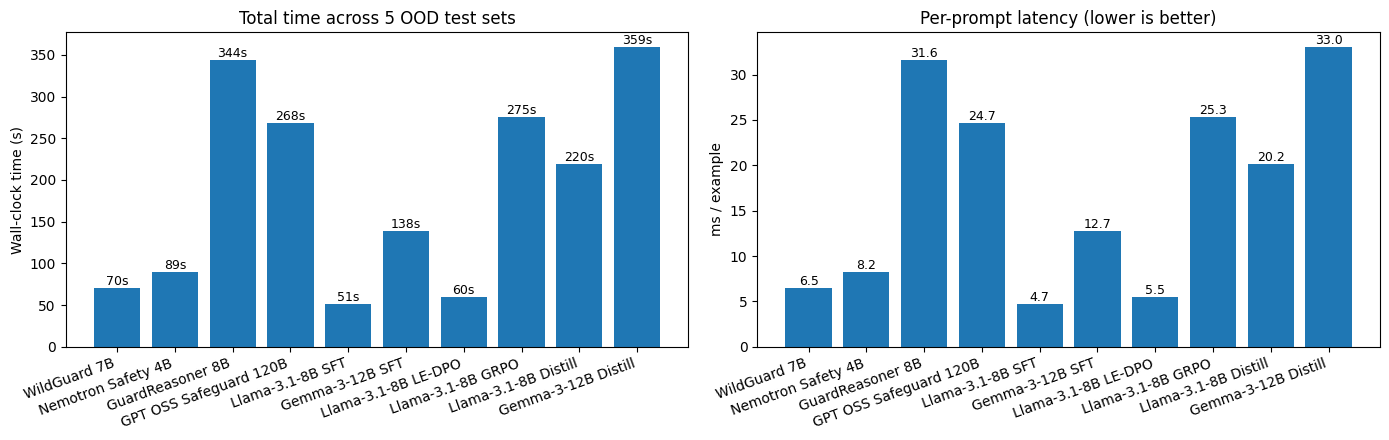

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: total wall-clock for the OOD suite
bars = axes[0].bar(suite['model'], suite['elapsed_s'])
axes[0].set_ylabel('Wall-clock time (s)')
axes[0].set_title('Total time across 5 OOD test sets')
axes[0].tick_params(axis='x', rotation=20)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')
for b, v in zip(bars, suite['elapsed_s']):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f'{v:.0f}s', ha='center', va='bottom', fontsize=9)

# Right: ms/example — the honest per-prompt latency (output-length agnostic)
bars = axes[1].bar(suite['model'], suite['ms_per_example'])
axes[1].set_ylabel('ms / example')
axes[1].set_title('Per-prompt latency (lower is better)')
axes[1].tick_params(axis='x', rotation=20)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')
for b, v in zip(bars, suite['ms_per_example']):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Tokens generated

Classification models (WildGuard, Nemotron) emit a single label token. Generation/reasoning models emit reasoning and structured output, so the per-example token count climbs sharply.

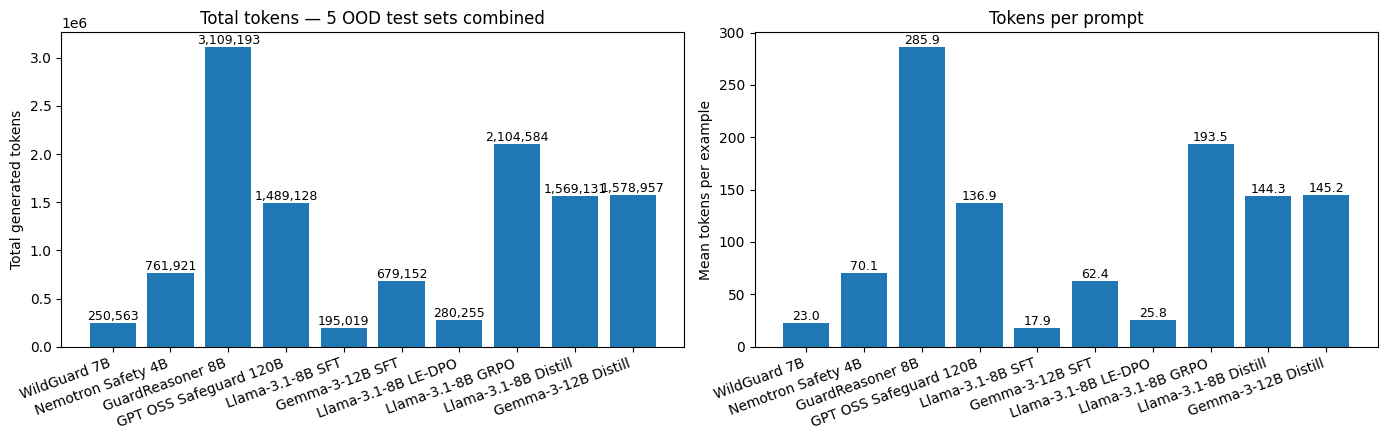

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(suite['model'], suite['total_tokens'])
axes[0].set_ylabel('Total generated tokens')
axes[0].set_title('Total tokens — 5 OOD test sets combined')
axes[0].tick_params(axis='x', rotation=20)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')
for x, v in enumerate(suite['total_tokens']):
    axes[0].text(x, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

axes[1].bar(suite['model'], suite['tokens_per_example'])
axes[1].set_ylabel('Mean tokens per example')
axes[1].set_title('Tokens per prompt')
axes[1].tick_params(axis='x', rotation=20)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')
for x, v in enumerate(suite['tokens_per_example']):
    axes[1].text(x, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Accuracy vs latency

The headline trade-off chart: mean OOD F1 (across the 5 OOD test sets) on the y-axis vs per-prompt latency (ms/example) on the x-axis. Upper-left is best — accurate and fast. Models on the Pareto frontier are simultaneously non-dominated.

The notebook recomputes F1 directly from each model's local `.jsonl` predictions when the suite summary's F1 is 0 — this transparently fixes the W&B parser-failure bug that affected some older runs (notably the Gemma SFT generation eval).

Saved: report/latex/img/pareto_f1_latency.pdf


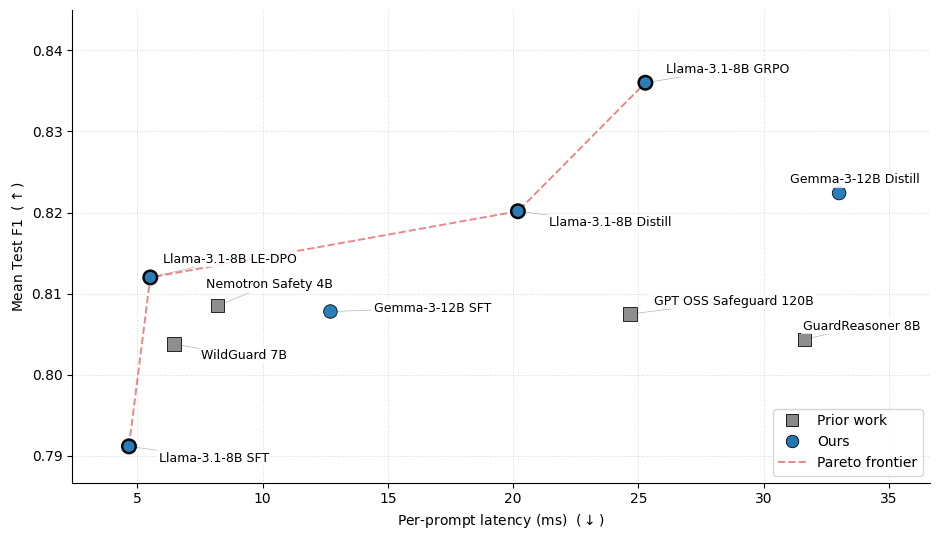

,model,group,kind,mean_ood_f1,ms_per_example,tokens_per_example,on_frontier
7,Llama-3.1-8B GRPO,ours,reasoning + intent (GRPO),0.8360,25.28,193.5,True
9,Gemma-3-12B Distill,ours,reasoning + human_intent,0.8224,33.01,145.2,False
8,Llama-3.1-8B Distill,ours,reasoning + synthetic_intent,0.8202,20.19,144.3,True
6,Llama-3.1-8B LE-DPO,ours,generation (LE-DPO),0.8120,5.52,25.8,True
1,Nemotron Safety 4B,prior,classification (reasoning),0.8085,8.20,70.1,False
5,Gemma-3-12B SFT,ours,generation,0.8078,12.71,62.4,False
3,GPT OSS Safeguard 120B,prior,classification (reasoning),0.8075,24.66,136.9,False
2,GuardReasoner 8B,prior,classification (reasoning),0.8044,31.63,285.9,False
0,WildGuard 7B,prior,classification (3-line),0.8038,6.46,23.0,False
4,Llama-3.1-8B SFT,ours,generation,0.7912,4.66,17.9,True


In [5]:
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox

scatter_df = suite.dropna(subset=['mean_ood_f1']).copy()
scatter_df = scatter_df[scatter_df['mean_ood_f1'] > 0]

# Pareto frontier: keep models that aren't dominated (lower ms/ex AND higher F1).
sorted_by_lat = scatter_df.sort_values('ms_per_example')
frontier_idx = []
best_f1 = -1.0
for idx, row in sorted_by_lat.iterrows():
    if row['mean_ood_f1'] > best_f1:
        frontier_idx.append(idx)
        best_f1 = row['mean_ood_f1']
frontier = scatter_df.loc[frontier_idx].sort_values('ms_per_example')
scatter_df['on_frontier'] = scatter_df.index.isin(frontier_idx)

# Group → marker style. Squares for prior work, circles for ours — gives a B&W /
# colorblind-safe distinction in addition to color.
GROUP_STYLE = {
    'prior': {'color': '#888888', 'marker': 's', 'label': 'Prior work'},
    'ours':  {'color': '#1f77b4', 'marker': 'o', 'label': 'Ours'},
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))

# Plot ranges (manual padding) so adjustText has headroom.
x_min, x_max = scatter_df['ms_per_example'].min(), scatter_df['ms_per_example'].max()
y_min, y_max = scatter_df['mean_ood_f1'].min(), scatter_df['mean_ood_f1'].max()
x_pad = (x_max - x_min) * 0.08
y_pad = (y_max - y_min) * 0.20
ax.set_xlim(x_min - x_pad, x_max + x_pad * 1.6)
ax.set_ylim(y_min - y_pad * 0.5, y_max + y_pad)

# Pareto frontier line.
front_x = frontier['ms_per_example'].to_numpy()
front_y = frontier['mean_ood_f1'].to_numpy()
ax.plot(front_x, front_y,
        color='tab:red', linestyle='--', alpha=0.55, linewidth=1.4,
        zorder=2)

# Markers per group; frontier points get a thicker outline so they pop.
for group, style in GROUP_STYLE.items():
    sub = scatter_df[scatter_df['group'] == group]
    if sub.empty:
        continue
    linewidths = np.where(sub['on_frontier'], 1.8, 0.6)
    ax.scatter(
        sub['ms_per_example'], sub['mean_ood_f1'],
        s=95, alpha=0.95, edgecolor='black', linewidths=linewidths,
        color=style['color'], marker=style['marker'],
        zorder=3,
    )

# Label placement.
texts = [
    ax.text(
        row['ms_per_example'], row['mean_ood_f1'], row['model'],
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.2),
        zorder=4,
    )
    for _, row in scatter_df.iterrows()
]
adjust_text(
    texts,
    x=scatter_df['ms_per_example'].to_numpy(dtype=float),
    y=scatter_df['mean_ood_f1'].to_numpy(dtype=float),
    ax=ax,
    expand=(1.4, 1.6),
    force_static=(0.5, 0.6),
    force_text=(0.3, 0.4),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.6),
)

# Minimalist axes — drop top/right spines, dotted grid.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.5)

ax.set_xlabel(r'Per-prompt latency (ms)  ($\downarrow$)')
ax.set_ylabel(r'Mean Test F1  ($\uparrow$)')

# Proxy legend handles so the "Ours" / "Prior work" swatches show the regular
# (non-frontier) marker style rather than picking up the thick-edged outline.
legend_handles = [
    Line2D([0], [0], marker=GROUP_STYLE['prior']['marker'], color='w',
           markerfacecolor=GROUP_STYLE['prior']['color'], markeredgecolor='black',
           markeredgewidth=0.6, markersize=9, label='Prior work'),
    Line2D([0], [0], marker=GROUP_STYLE['ours']['marker'], color='w',
           markerfacecolor=GROUP_STYLE['ours']['color'], markeredgecolor='black',
           markeredgewidth=0.6, markersize=9, label='Ours'),
    Line2D([0], [0], color='tab:red', linestyle='--', linewidth=1.4, alpha=0.55,
           label='Pareto frontier'),
]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()

# Symmetric save bbox: pad whichever side is shorter so the axes' horizontal
# centre sits at the centre of the saved PDF. Without this the y-axis label +
# tick labels protrude to the left, so a LaTeX caption underneath would look
# off-centre relative to the data area.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
tight_bbox = fig.get_tightbbox(renderer)  # inches
ax_disp = ax.get_window_extent(renderer)
inv = fig.dpi_scale_trans.inverted()
ax_x0_in, _ = inv.transform((ax_disp.x0, 0))
ax_x1_in, _ = inv.transform((ax_disp.x1, 0))
ax_cx = (ax_x0_in + ax_x1_in) / 2
half_w = max(ax_cx - tight_bbox.x0, tight_bbox.x1 - ax_cx)
sym_bbox = Bbox.from_extents(ax_cx - half_w, tight_bbox.y0,
                             ax_cx + half_w, tight_bbox.y1)

fig_out = REPO / 'report' / 'latex' / 'img' / 'pareto_f1_latency.pdf'
fig_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_out, bbox_inches=sym_bbox)
print(f'Saved: {fig_out.relative_to(REPO)}')

plt.show()

# Numeric companion
scatter_df[['model', 'group', 'kind', 'mean_ood_f1', 'ms_per_example', 'tokens_per_example', 'on_frontier']]\
    .sort_values('mean_ood_f1', ascending=False)\
    .round({'mean_ood_f1': 4, 'ms_per_example': 2, 'tokens_per_example': 1})

## Per-dataset breakdown

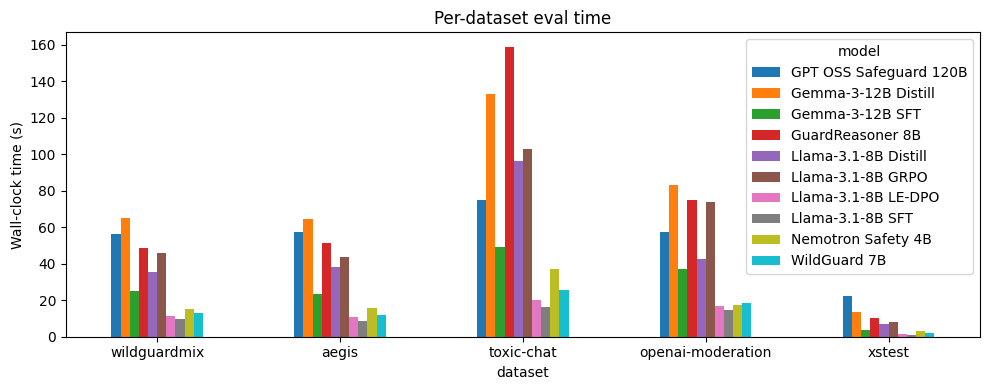

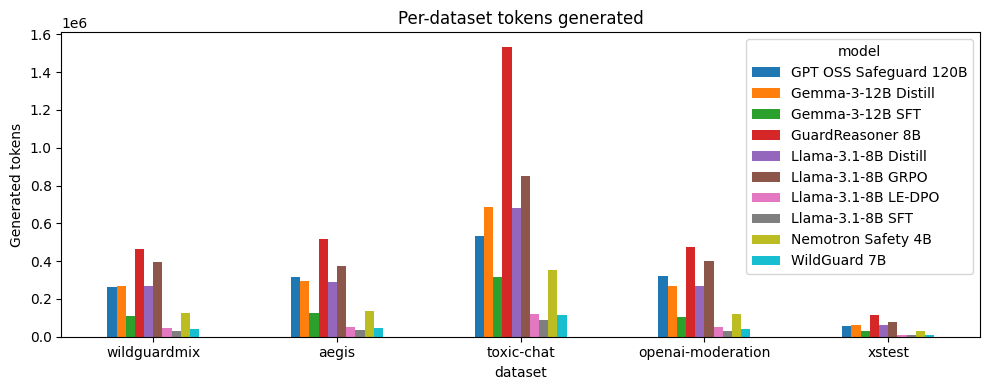

In [6]:
pivot_time = per_ds.pivot(index='dataset', columns='model', values='elapsed_s').reindex(OOD_DATASETS)
ax = pivot_time.plot.bar(figsize=(10, 4))
ax.set_ylabel('Wall-clock time (s)')
ax.set_title('Per-dataset eval time')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot_tokens = per_ds.pivot(index='dataset', columns='model', values='total_tokens').reindex(OOD_DATASETS)
ax = pivot_tokens.plot.bar(figsize=(10, 4))
ax.set_ylabel('Generated tokens')
ax.set_title('Per-dataset tokens generated')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Numeric table for the paper

In [7]:
display_suite = suite[['model', 'kind', 'total_examples', 'total_tokens',
                       'tokens_per_example', 'elapsed_s', 'ms_per_example',
                       'examples_per_second', 'tokens_per_second']].copy()
display_suite.columns = ['Model', 'Output kind', 'N examples', 'Tokens',
                         'Tokens/example', 'Time (s)', 'ms/example',
                         'Examples/s', 'Throughput (tok/s)']
display_suite.round({'Tokens/example': 1, 'Time (s)': 1,
                     'ms/example': 2, 'Examples/s': 1,
                     'Throughput (tok/s)': 1})

,Model,Output kind,N examples,Tokens,Tokens/example,Time (s),ms/example,Examples/s,Throughput (tok/s)
0,WildGuard 7B,classification (3-line),10876,250563,23.0,70.3,6.46,154.7,3565.1
1,Nemotron Safety 4B,classification (reasoning),10876,761921,70.1,89.2,8.20,122.0,8545.3
2,GuardReasoner 8B,classification (reasoning),10876,3109193,285.9,344.1,31.63,31.6,9036.8
3,GPT OSS Safeguard 120B,classification (reasoning),10876,1489128,136.9,268.2,24.66,40.6,5552.9
4,Llama-3.1-8B SFT,generation,10876,195019,17.9,50.7,4.66,214.4,3844.8
5,Gemma-3-12B SFT,generation,10876,679152,62.4,138.2,12.71,78.7,4914.9
6,Llama-3.1-8B LE-DPO,generation (LE-DPO),10876,280255,25.8,60.0,5.52,181.3,4672.2
7,Llama-3.1-8B GRPO,reasoning + intent (GRPO),10876,2104584,193.5,274.9,25.28,39.6,7655.6
8,Llama-3.1-8B Distill,reasoning + synthetic_intent,10876,1569131,144.3,219.6,20.19,49.5,7146.4
9,Gemma-3-12B Distill,reasoning + human_intent,10876,1578957,145.2,359.0,33.01,30.3,4398.2
